# FC-substituted attention: does forcing real FC into the diagonal blocks change reconstruction?

`fc_attention_correlation.ipynb` found that the last encoder layer's region x region
attention (averaged over heads, held at one time-patch) correlates with that
time-patch's functional connectivity (FC) at r~0.12, and with whole-series FC at
r~0.43. That's a correlation, not identity. This notebook tests the stronger claim
directly: **forcibly replace** each same-time-patch 424x424 attention block with the
*actual* FC computed from this subject's raw 200-TR window, renormalize so attention
still sums to 1, and see whether the model's masked-token reconstruction (the exact
future-vs-random task from `future_vs_random_token_reconstruction.ipynb`) survives,
improves, or degrades. If the hypothesis "diagonal blocks *are* FC" were true, this
substitution should barely move reconstruction quality; if the learned attention is
doing something FC alone can't capture, quality should drop.

## Why this isn't just visualization -- and why it's more involved than it sounds

`fc_attention_correlation.ipynb` only *read* attention (`output_attentions=True`) on an
otherwise unmasked forward pass, purely for comparison. Actually **substituting** it
requires intervening mid-forward-pass in the real computation, and two architectural
facts complicate the "replace the diagonal 424x424 blocks of the 4240x4240 matrix"
framing from a first pass at this:

1. **The encoder's last-layer attention checkpoint here IS exact softmax, not an
   approximation.** `BrainLMEncoder` uses `NystromformerLayer`, which is normally a
   linear-attention approximation via landmark points -- but
   `NystromformerSelfAttention.forward` has a special-case branch
   (`if self.num_landmarks == self.seq_len`) that falls back to *exact* full softmax
   attention when the two are equal. The `old_13M` checkpoint's config has
   `num_landmarks=64` and `segment_means_seq_len=64` -- equal -- so every layer,
   including the last, computes genuine `softmax(QK^T/sqrt(d))` and uses it directly
   for `context = attention_probs @ V`. Verified empirically below: attention rows
   sum to 1 to float precision. This is what makes a *causal* substitution
   (not just a visual one) tractable at all -- there's a real, single attention
   matrix in the actual computation graph to intervene on.

2. **Masking shrinks the encoder's attention matrix -- it isn't 4240x4240 once any
   token is masked.** The encoder only ever sees *unmasked* tokens (masked ones are
   injected as blank `mask_token` embeddings later, inside the *decoder*, using
   `ids_restore`). With this notebook's `mask_ratio=1/num_patches` (same one masked
   patch per region as before, independently per region -- same "future" and "random"
   conditions, unchanged from `future_vs_random_token_reconstruction.ipynb`), the
   encoder's last-layer attention is only `(seq_len - num_regions + 1) x (...)` --
   about 3817x3817, not 4241x4241. Since masking is independent *per region*, whichever
   regions happen to keep a given time-patch varies patch by patch -- so instead of
   10 clean 424x424 diagonal blocks, most patches have a 424-minus-a-few-region block.
   FC gets substituted in at whatever size is actually present (an "incomplete FC"),
   restricted via `ids_restore` to just those regions -- not silently padded or
   skipped. A patch with zero regions present (only happens in the deterministic
   "future" condition, where patch `num_patches-1` is masked for literally everyone)
   is left alone since there's nothing there to replace.

## Mechanism

A `forward_hook` on `model.vit.encoder.layer[-1].attention.self` intercepts that
module's own output -- `(context_layer, attention_probs)` -- right after the real
softmax is computed. It rebuilds `attention_probs` (splicing in the FC submatrix at
each time-patch's positions, restricted to whichever regions are actually present),
renormalizes every row back to sum to 1, and **recomputes** `context_layer` from
this modified attention using the module's own (real, trained) `value` projection
and depthwise `conv` term -- exactly mirroring `NystromformerSelfAttention.forward`'s
own arithmetic. The hook's return value replaces the module's real output, so
everything downstream (the self-output residual+layernorm, the FFN, the decoder)
consumes the FC-substituted representation, not the original one.

**Caveat**: FC (Pearson r) can be negative, unlike softmax attention weights (always
non-negative). Splicing raw FC values into a row and renormalizing by the new row
sum can leave some entries negative -- this is a deliberate, literal test of the
substitution hypothesis, not an attempt to produce a well-formed probability
distribution.

Everything else -- the future/random masking design, the per-region Pearson r
metric, the single-subject + 25-subject-pooled structure -- is unchanged from
`future_vs_random_token_reconstruction.ipynb`, specifically so the two notebooks'
results are directly comparable (same `RANDOM_SEED`, same per-subject reseeding, so
the *same* patches get masked in both).

In [1]:
import os
import sys
import csv

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

torch.set_num_threads(MAX_CPU_THREADS)

sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data

get_ipython().run_line_magic("matplotlib", "inline")

In [2]:
# --- Config ---
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"

SUBJECT_INDEX = 0
WINDOW_INDEX = 0
NUM_WINDOWS = 3
WINDOW_SIZE = 200

RANDOM_SEED = 0             # same as future_vs_random_token_reconstruction.ipynb -> identical masked patches
N_SUBJECTS_MULTI = 25       # same as before, for a directly comparable pooled result
N_EXAMPLES_PER_CONDITION = 3

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

ORIGINAL_MODEL_CSV = os.path.join(OUTPUTS_DIR, "future_vs_random_w0_correlations.csv")  # from the prior notebook

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()

spatial_coords = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
FUTURE_PATCH_IDX = num_patches - 1

MASK_RATIO = num_regions / seq_len
model.config.mask_ratio = MASK_RATIO

print(f"num_regions={num_regions}, num_patches={num_patches}, patch_size={patch_size}, seq_len={seq_len}")
print(f"mask_ratio={MASK_RATIO:.4f}, num_landmarks={config.num_landmarks}, segment_means_seq_len={config.segment_means_seq_len}")
print(f"encoder uses exact softmax attention: {config.num_landmarks == config.segment_means_seq_len}")

Device: cpu


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


num_regions=424, num_patches=10, patch_size=20, seq_len=4240
mask_ratio=0.1000, num_landmarks=64, segment_means_seq_len=64
encoder uses exact softmax attention: True


## Helpers

Reused unchanged from `future_vs_random_token_reconstruction.ipynb`: `token_index`,
`build_exact_mask_noise`, `per_region_patch_correlation`. New for this notebook:
`compute_fc`, `make_fc_attention_hook`, and `predict_exact_patches_fc_injected` (the
FC-substituted counterpart to that notebook's `predict_exact_patches`).

In [4]:
def token_index(region, patch, num_patches):
    return region * num_patches + patch


def build_exact_mask_noise(mask_token_indices, seq_len, device):
    """noise s.t. argsort(noise, dim=1) puts exactly `mask_token_indices` into the
    largest-valued positions -- random_masking then masks exactly those tokens,
    given mask_ratio == len(mask_token_indices) / seq_len."""
    noise = torch.rand(1, seq_len, device=device)                    # "keep" side, [0, 1)
    idx = torch.as_tensor(mask_token_indices, device=device, dtype=torch.long).unsqueeze(0)
    mask_vals = 1.0 + torch.rand(1, idx.shape[1], device=device)      # "mask" side, [1, 2)
    noise.scatter_(dim=1, index=idx, src=mask_vals)
    return noise


def per_region_patch_correlation(predicted, masked_bool, raw_window, patch_size):
    """One Pearson r per region: predicted vs. real, over that region's single masked
    20-TR patch only. raw_window: [num_regions, window_size], in raw (unscaled) units.
    """
    num_regions = predicted.shape[0]
    r_values = np.full(num_regions, np.nan)
    patch_used = np.full(num_regions, -1, dtype=int)
    for region in range(num_regions):
        patches = np.flatnonzero(masked_bool[region])
        if len(patches) != 1:
            raise RuntimeError(f"region {region}: expected exactly 1 masked patch, got {len(patches)}")
        patch = int(patches[0])
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        r_values[region] = np.corrcoef(raw_window[region, tr_lo:tr_hi], predicted[region, patch, :])[0, 1]
        patch_used[region] = patch
    return r_values, patch_used


def compute_fc(raw_window):
    """Pearson correlation matrix of a [num_regions, window_size] raw time series."""
    return np.corrcoef(raw_window)


def make_fc_attention_hook(fc_matrix, kept_original_indices, num_patches, diagnostics=None):
    """forward_hook for NystromformerSelfAttention (the last encoder layer only).
    `kept_original_indices[j]` is the ORIGINAL flat (region*num_patches+patch) index of
    whichever token occupies position j of the encoder's reduced (masked) sequence --
    from argsort(ids_restore)[:len_keep], since the encoder only ever sees kept tokens.

    For each time-patch t, replaces the attention entries among positions that share
    patch==t with the FC submatrix restricted to just those regions (this block is
    "incomplete" -- smaller than 424x424 -- whenever some regions masked patch t and
    others didn't), renormalizes every row back to sum to 1, then recomputes
    context_layer from the modified attention using the module's own (real) value
    projection and conv term -- mirroring NystromformerSelfAttention.forward exactly,
    just with attention_probs swapped out.

    `fc_matrix` can have negative entries (raw FC) or not (e.g. np.abs(fc)) --
    the row-sum used for renormalization is computed either way, and if `diagnostics`
    is a dict, the pre-renormalization row sums are stashed into it as
    `diagnostics["row_sums_pre_renorm"]` (a numpy array) so the caller can check
    whether any row's sum went negative (which flips that row's sign on division --
    see the "FC vs. abs(FC)" section below).
    """
    region_of = kept_original_indices // num_patches
    patch_of = kept_original_indices % num_patches

    def hook(module, inputs, output):
        hidden_states = inputs[0]
        _, attn_probs = output  # attn_probs: [batch, heads, 1+len_keep, 1+len_keep]; row/col 0 = CLS
        modified = attn_probs.clone()

        for t in range(num_patches):
            pos = np.flatnonzero(patch_of == t)
            if len(pos) == 0:
                continue  # this patch has zero regions present (only happens for a fully-uniform mask)
            regions_t = region_of[pos]
            fc_sub = fc_matrix[np.ix_(regions_t, regions_t)]
            fc_sub_t = torch.as_tensor(fc_sub, dtype=modified.dtype, device=modified.device)
            idx_t = torch.as_tensor(pos, dtype=torch.long, device=modified.device) + 1  # +1 for CLS offset
            modified[:, :, idx_t[:, None], idx_t[None, :]] = fc_sub_t

        row_sums_pre_renorm = modified.sum(dim=-1)
        if diagnostics is not None:
            diagnostics["row_sums_pre_renorm"] = row_sums_pre_renorm.detach().cpu().numpy()
        modified = modified / row_sums_pre_renorm.unsqueeze(-1)  # restore row-sums-to-1

        value_layer = module.transpose_for_scores(module.value(hidden_states))
        context = torch.matmul(modified, value_layer)
        if module.conv_kernel_size is not None:
            context = context + module.conv(value_layer)
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(*(context.size()[:-2] + (module.all_head_size,)))
        return (context, modified)

    return hook


def predict_exact_patches_fc_injected(model, x, spatial_coords, mask_token_indices, fc_matrix, num_regions, num_patches, diagnostics=None):
    """Like predict_exact_patches (future_vs_random_token_reconstruction.ipynb), but the
    last encoder layer's attention has its same-time-patch blocks replaced with `fc_matrix`
    (see make_fc_attention_hook) before the rest of the forward pass -- including the
    decoder's actual prediction -- runs on top of it. Requires model.config.mask_ratio ==
    len(mask_token_indices) / (num_regions * num_patches). Pass a dict as `diagnostics` to
    get the pre-renormalization row sums back (see make_fc_attention_hook).
    """
    seq_len = num_regions * num_patches
    noise = build_exact_mask_noise(mask_token_indices, seq_len, x.device)

    with torch.no_grad():
        _, _, ids_restore = model.vit.embeddings(x, spatial_coords, noise)
    len_keep = seq_len - len(mask_token_indices)
    ids_shuffle = torch.argsort(ids_restore, dim=1)
    kept_original_indices = ids_shuffle[0, :len_keep].cpu().numpy()

    handle = model.vit.encoder.layer[-1].attention.self.register_forward_hook(
        make_fc_attention_hook(fc_matrix, kept_original_indices, num_patches, diagnostics=diagnostics)
    )
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)
    finally:
        handle.remove()

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits
    predicted = logits[0].detach().cpu().numpy()
    masked_bool = out.mask[0].detach().cpu().numpy().astype(bool)

    expected = {(idx // num_patches, idx % num_patches) for idx in mask_token_indices}
    actual = {tuple(rc) for rc in np.argwhere(masked_bool)}
    if actual != expected:
        raise RuntimeError(
            f"Model masked a different token set than requested: "
            f"{len(actual)} actual vs {len(expected)} expected "
            f"(symmetric difference size={len(actual ^ expected)})."
        )
    return predicted, masked_bool

## Attention-sum sanity check (single subject) -- and why abs(FC) too

FC (Pearson r) can be negative; softmax attention isn't. Splicing raw FC into a row
and dividing by that row's new sum only recovers "sums to 1" in the literal sense --
if the injected FC values are negative enough that the row's sum flips negative
*before* the division, dividing by a negative number flips the sign of *everything*
in that row, including the untouched, originally-positive real attention entries.
Checked directly below: this does happen for a real subject/condition (a
meaningful fraction of rows), but using `np.abs(fc_matrix)` instead removes the
failure mode entirely -- abs(FC) >= 0 and the untouched attention entries are
already >= 0 (softmax), so their sum can never go negative, and dividing by it never
flips a sign. Both variants are carried through the rest of the notebook so the
*actual reconstruction impact* of that difference can be measured, not just asserted.

In [5]:
with h5py.File(INPUT_H5, "r") as f:
    sub_id = f["subject_ids"][SUBJECT_INDEX].decode("utf-8")
    raw_data = f["parcel_ts"][SUBJECT_INDEX, :, :]

if np.isnan(raw_data[:WINDOW_SIZE, :]).any():
    raise ValueError(f"{sub_id}: NaNs in the first {WINDOW_SIZE} TRs; window-0 alignment would break.")

fmri_windows = preprocess_subject_data(raw_data, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
x = fmri_windows[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)
raw_window = raw_data[:WINDOW_SIZE, :].T
fc_matrix = compute_fc(raw_window)
fc_matrix_abs = np.abs(fc_matrix)  # see "FC vs. abs(FC)" section below

future_mask_indices = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]

noise_check = build_exact_mask_noise(future_mask_indices, seq_len, device)
with torch.no_grad():
    _, _, ids_restore_check = model.vit.embeddings(x, spatial_coords, noise_check)
len_keep_check = seq_len - len(future_mask_indices)
ids_shuffle_check = torch.argsort(ids_restore_check, dim=1)
kept_idx_check = ids_shuffle_check[0, :len_keep_check].cpu().numpy()
region_of_check = kept_idx_check // num_patches
patch_of_check = kept_idx_check % num_patches

block_sizes = [int((patch_of_check == t).sum()) for t in range(num_patches)]
print(f"regions present per diagonal block, future condition (patch {FUTURE_PATCH_IDX} masked for everyone): {block_sizes}")

with torch.no_grad():
    out_before = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise_check)
attn_before = out_before.attentions[-1]
sums_before = attn_before.sum(dim=-1)
print(f"BEFORE substitution -- attention shape={tuple(attn_before.shape)}, row sums min={sums_before.min().item():.6f}, max={sums_before.max().item():.6f}")

diag_fc, diag_abs = {}, {}
handle = model.vit.encoder.layer[-1].attention.self.register_forward_hook(
    make_fc_attention_hook(fc_matrix, kept_idx_check, num_patches, diagnostics=diag_fc)
)
with torch.no_grad():
    out_after = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise_check)
handle.remove()
attn_after = out_after.attentions[-1]
sums_after = attn_after.sum(dim=-1)
print(f"AFTER substitution   -- row sums min={sums_after.min().item():.6f}, max={sums_after.max().item():.6f}")
pre_fc = diag_fc["row_sums_pre_renorm"]
print(f"  pre-renorm row sums: min={pre_fc.min():.4f}, max={pre_fc.max():.4f}, "
      f"negative rows={int((pre_fc < 0).sum())}/{pre_fc.size} "
      f"(each one flips that row's sign on division -- see write-up)")

handle = model.vit.encoder.layer[-1].attention.self.register_forward_hook(
    make_fc_attention_hook(fc_matrix_abs, kept_idx_check, num_patches, diagnostics=diag_abs)
)
with torch.no_grad():
    out_after_abs = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise_check)
handle.remove()
sums_after_abs = out_after_abs.attentions[-1].sum(dim=-1)
print(f"AFTER substitution (abs(FC))    -- row sums min={sums_after_abs.min().item():.6f}, max={sums_after_abs.max().item():.6f}")
pre_abs = diag_abs["row_sums_pre_renorm"]
print(f"  pre-renorm row sums: min={pre_abs.min():.4f}, max={pre_abs.max():.4f}, "
      f"negative rows={int((pre_abs < 0).sum())}/{pre_abs.size} "
      f"(abs(FC) >= 0 and original attention >= 0, so this can never go negative)")

logits_before = out_before.logits[0] if isinstance(out_before.logits, tuple) else out_before.logits
logits_after = out_after.logits[0] if isinstance(out_after.logits, tuple) else out_after.logits
diff = (logits_before - logits_after).abs()
print(f"\ndecoder logits changed : mean abs diff={diff.mean().item():.4f}, max abs diff={diff.max().item():.4f}")

regions present per diagonal block, future condition (patch 9 masked for everyone): [424, 424, 424, 424, 424, 424, 424, 424, 424, 0]


BEFORE substitution -- attention shape=(1, 4, 3817, 3817), row sums min=1.000000, max=1.000001


AFTER substitution   -- row sums min=0.999981, max=1.000015
  pre-renorm row sums: min=-5.6510, max=73.9439, negative rows=378/15268 (each one flips that row's sign on division -- see write-up)


AFTER substitution (abs(FC))    -- row sums min=1.000000, max=1.000000
  pre-renorm row sums: min=1.0000, max=88.9940, negative rows=0/15268 (abs(FC) >= 0 and original attention >= 0, so this can never go negative)

decoder logits changed : mean abs diff=0.3408, max abs diff=3.4642


## Do all heads look like FC, or just some of them?

The substitution above broadcasts the *same* `fc_matrix` to every attention head
(`modified[:, :, idx_t[:, None], idx_t[None, :]] = fc_sub_t` assigns a 2D tensor into
a `[batch, heads, ...]` slice -- it broadcasts identically across heads, not a
per-head FC). Before trusting that as a reasonable stand-in for "the diagonal
blocks", it's worth checking whether the *original* heads actually agree with each
other and with FC in the first place -- if only one head resembles FC and the other
three are doing something else, forcing all four to FC throws away whatever
those other heads specialized in, and the causal effect measured above is really
"replace 4 heads' routing with FC", not "confirm FC is what all heads already do".

`config.num_attention_heads = 4` for `old_13M`. Using `attn_before` (already computed,
`future` condition) and a full 424-region diagonal block (patch 0, since patch
`FUTURE_PATCH_IDX` is the only one fully masked out): pairwise head-vs-head
correlation of that block, and each head's own correlation with FC.

head-vs-head correlation of this diagonal block (off-diagonal ~0 => heads disagree):
[[ 1.    -0.018  0.164 -0.027]
 [-0.018  1.    -0.039  0.005]
 [ 0.164 -0.039  1.     0.013]
 [-0.027  0.005  0.013  1.   ]]

per-head r(attention block, FC): [ 0.0708 -0.0504  0.4486  0.0745]
head-AVERAGED r(attention block, FC): 0.3669


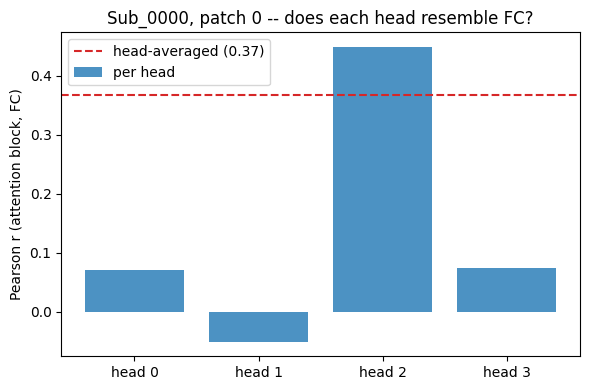


If per-head r values are uneven (some near the head-average or higher, others near zero), the head-averaged correlation fc_attention_correlation.ipynb reported is being carried by a subset of heads -- broadcasting FC to every head (as the substitution above does) replaces heads that already look like FC AND heads that don't.


In [6]:
t_full = 0  # any patch other than FUTURE_PATCH_IDX has all 424 regions present here
pos_full = np.flatnonzero(patch_of_check == t_full)
assert len(pos_full) == num_regions, f"expected a full block, got {len(pos_full)} regions"
regions_full = region_of_check[pos_full]
order = np.argsort(regions_full)  # sort back into region-index order to align with fc_matrix
idx_full = torch.as_tensor(pos_full[order], dtype=torch.long) + 1  # +1 for CLS offset

blocks_by_head = attn_before[0, :, idx_full[:, None], idx_full[None, :]].numpy()  # [heads, 424, 424]
num_heads = blocks_by_head.shape[0]

head_flat = blocks_by_head.reshape(num_heads, -1)
head_vs_head = np.corrcoef(head_flat)
print("head-vs-head correlation of this diagonal block (off-diagonal ~0 => heads disagree):")
print(np.round(head_vs_head, 3))

fc_flat = fc_matrix.ravel()
head_vs_fc = np.array([np.corrcoef(blocks_by_head[h].ravel(), fc_flat)[0, 1] for h in range(num_heads)])
mean_block_vs_fc = np.corrcoef(blocks_by_head.mean(axis=0).ravel(), fc_flat)[0, 1]
print("\nper-head r(attention block, FC):", np.round(head_vs_fc, 4))
print(f"head-AVERAGED r(attention block, FC): {mean_block_vs_fc:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar([f"head {h}" for h in range(num_heads)], head_vs_fc, color="tab:blue", alpha=0.8, label="per head")
ax.axhline(mean_block_vs_fc, color="tab:red", linestyle="--", label=f"head-averaged ({mean_block_vs_fc:.2f})")
ax.set_ylabel("Pearson r (attention block, FC)")
ax.set_title(f"{sub_id}, patch {t_full} -- does each head resemble FC?")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_per_head_vs_fc.png"), dpi=130, bbox_inches="tight")
plt.show()

print(
    "\nIf per-head r values are uneven (some near the head-average or higher, others near "
    "zero), the head-averaged correlation fc_attention_correlation.ipynb reported is being "
    "carried by a subset of heads -- broadcasting FC to every head (as the substitution "
    "above does) replaces heads that already look like FC AND heads that don't."
)

## Single subject (Sub_0000): future vs. random, FC-substituted attention

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
random_patch_per_region = rng.integers(0, num_patches, size=num_regions)
random_mask_indices = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_per_region)]

pred_future, mask_future = predict_exact_patches_fc_injected(model, x, spatial_coords, future_mask_indices, fc_matrix, num_regions, num_patches)
pred_random, mask_random = predict_exact_patches_fc_injected(model, x, spatial_coords, random_mask_indices, fc_matrix, num_regions, num_patches)
pred_future_abs, mask_future_abs = predict_exact_patches_fc_injected(model, x, spatial_coords, future_mask_indices, fc_matrix_abs, num_regions, num_patches)
pred_random_abs, mask_random_abs = predict_exact_patches_fc_injected(model, x, spatial_coords, random_mask_indices, fc_matrix_abs, num_regions, num_patches)

r_future, patch_future = per_region_patch_correlation(pred_future, mask_future, raw_window, patch_size)
r_random, patch_random = per_region_patch_correlation(pred_random, mask_random, raw_window, patch_size)
r_future_abs, patch_future_abs = per_region_patch_correlation(pred_future_abs, mask_future_abs, raw_window, patch_size)
r_random_abs, patch_random_abs = per_region_patch_correlation(pred_random_abs, mask_random_abs, raw_window, patch_size)

print(f"{sub_id}, window {WINDOW_INDEX} (TR 0-{WINDOW_SIZE})")
print(f"  future, FC      : mean r={np.nanmean(r_future):.3f}, median r={np.nanmedian(r_future):.3f}, std={np.nanstd(r_future):.3f}")
print(f"  future, abs(FC)   : mean r={np.nanmean(r_future_abs):.3f}, median r={np.nanmedian(r_future_abs):.3f}, std={np.nanstd(r_future_abs):.3f}")
print(f"  random, FC      : mean r={np.nanmean(r_random):.3f}, median r={np.nanmedian(r_random):.3f}, std={np.nanstd(r_random):.3f}")
print(f"  random, abs(FC)   : mean r={np.nanmean(r_random_abs):.3f}, median r={np.nanmedian(r_random_abs):.3f}, std={np.nanstd(r_random_abs):.3f}")

Sub_0000, window 0 (TR 0-200)
  future, FC      : mean r=0.029, median r=0.020, std=0.275
  future, abs(FC)   : mean r=-0.007, median r=-0.011, std=0.269
  random, FC      : mean r=0.361, median r=0.396, std=0.333
  random, abs(FC)   : mean r=0.259, median r=0.259, std=0.347


### Visual sanity check: best-reconstructed regions per condition

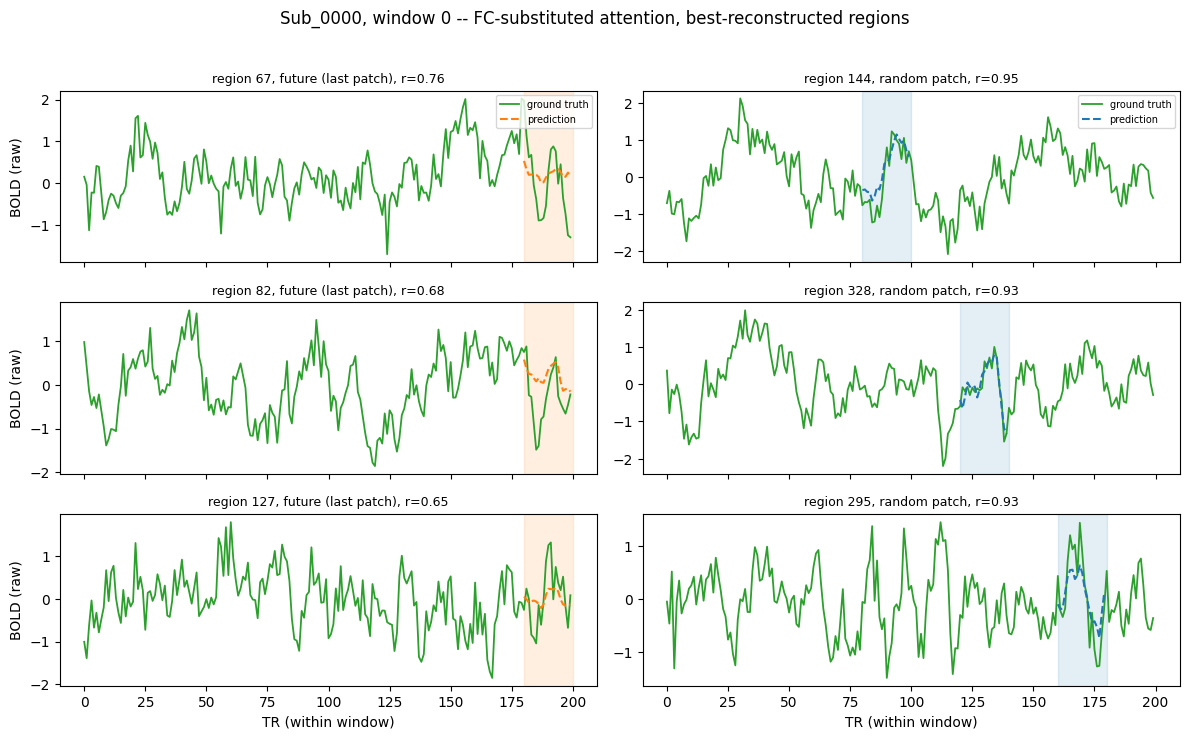

In [8]:
conditions = [
    ("future (last patch)", pred_future, patch_future, r_future, "tab:orange"),
    ("random patch", pred_random, patch_random, r_random, "tab:blue"),
]

top_regions_per_condition = [
    np.argsort(np.nan_to_num(r_vals, nan=-np.inf))[-N_EXAMPLES_PER_CONDITION:][::-1]
    for (_, _, _, r_vals, _) in conditions
]

fig, axes = plt.subplots(N_EXAMPLES_PER_CONDITION, 2, figsize=(12, 2.4 * N_EXAMPLES_PER_CONDITION), sharex=True)

for col, ((label, pred, patch_pos, r_vals, color), top_regions) in enumerate(zip(conditions, top_regions_per_condition)):
    for row, region in enumerate(top_regions):
        ax = axes[row, col]
        ax.plot(raw_window[region], color="tab:green", linewidth=1.3, label="ground truth")
        patch = patch_pos[region]
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        ax.plot(range(tr_lo, tr_hi), pred[region, patch, :], color=color, linewidth=1.5,
                linestyle="--", label="prediction")
        ax.axvspan(tr_lo, tr_hi, color=color, alpha=0.12)
        ax.set_title(f"region {region}, {label}, r={r_vals[region]:.2f}", fontsize=9)
        if row == 0:
            ax.legend(fontsize=7, loc="upper right")
        if col == 0:
            ax.set_ylabel("BOLD (raw)")

axes[-1, 0].set_xlabel("TR (within window)")
axes[-1, 1].set_xlabel("TR (within window)")
fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- FC-substituted attention, best-reconstructed regions", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_fc_substituted_best_examples.png"), dpi=130, bbox_inches="tight")
plt.show()

### Distribution comparison (single subject, all regions)

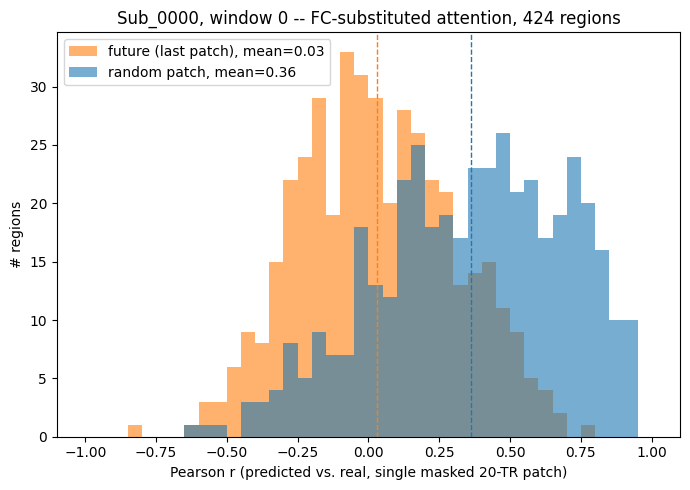

Paired Wilcoxon signed-rank (future vs. random, same regions, n=424): statistic=11612.0, p=4.896e-40


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future, bins=bins, alpha=0.6, color="tab:orange", label=f"future (last patch), mean={np.nanmean(r_future):.2f}")
ax.hist(r_random, bins=bins, alpha=0.6, color="tab:blue", label=f"random patch, mean={np.nanmean(r_random):.2f}")
ax.axvline(np.nanmean(r_future), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# regions")
ax.set_title(f"{sub_id}, window {WINDOW_INDEX} -- FC-substituted attention, {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_fc_substituted_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid = ~(np.isnan(r_future) | np.isnan(r_random))
stat, p = stats.wilcoxon(r_future[valid], r_random[valid])
print(f"Paired Wilcoxon signed-rank (future vs. random, same regions, n={int(valid.sum())}): statistic={stat:.1f}, p={p:.4g}")

## Multi-subject pooled comparison

Same procedure for the first `N_SUBJECTS_MULTI` subjects, same `RANDOM_SEED +
subject_index` reseeding as `future_vs_random_token_reconstruction.ipynb` -- so the
per-region random patch choices are identical between the two notebooks, and any
difference in the resulting r-distributions is attributable to the FC substitution,
not to different tokens having been masked. Both the FC and abs(FC) variants
are run for every subject, tagged with a `variant` column, so the reconstruction
impact of the sign issue above can be measured directly rather than just argued from
one subject's row-sum counts.

In [10]:
multi_results = []  # rows: subject_id, region, condition, variant, patch, tr_start, tr_end, r
skipped_subjects = []

for subject_index in range(N_SUBJECTS_MULTI):
    with h5py.File(INPUT_H5, "r") as f:
        sub_id_m = f["subject_ids"][subject_index].decode("utf-8")
        raw_data_m = f["parcel_ts"][subject_index, :, :]

    if np.isnan(raw_data_m[:WINDOW_SIZE, :]).any():
        skipped_subjects.append(sub_id_m)
        print(f"{sub_id_m}: skipped (NaNs in first {WINDOW_SIZE} TRs)")
        continue

    fmri_windows_m = preprocess_subject_data(raw_data_m, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
    x_m = fmri_windows_m[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)
    raw_window_m = raw_data_m[:WINDOW_SIZE, :].T
    fc_matrix_m = compute_fc(raw_window_m)
    fc_matrix_abs_m = np.abs(fc_matrix_m)

    future_idx_m = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]
    rng_m = np.random.default_rng(RANDOM_SEED + subject_index)
    random_patch_m = rng_m.integers(0, num_patches, size=num_regions)
    random_idx_m = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_m)]

    per_variant_r = {}
    for variant_name, fc_for_variant in [("fc", fc_matrix_m), ("abs", fc_matrix_abs_m)]:
        pred_future_m, mask_future_m = predict_exact_patches_fc_injected(model, x_m, spatial_coords, future_idx_m, fc_for_variant, num_regions, num_patches)
        pred_random_m, mask_random_m = predict_exact_patches_fc_injected(model, x_m, spatial_coords, random_idx_m, fc_for_variant, num_regions, num_patches)

        r_future_m, patch_future_m = per_region_patch_correlation(pred_future_m, mask_future_m, raw_window_m, patch_size)
        r_random_m, patch_random_m = per_region_patch_correlation(pred_random_m, mask_random_m, raw_window_m, patch_size)
        per_variant_r[variant_name] = (r_future_m, r_random_m)

        for region in range(num_regions):
            for condition, patch_arr, r_arr in [("future", patch_future_m, r_future_m), ("random", patch_random_m, r_random_m)]:
                patch = int(patch_arr[region])
                multi_results.append({
                    "subject_id": sub_id_m, "region": region, "condition": condition, "variant": variant_name,
                    "patch": patch, "tr_start": patch * patch_size, "tr_end": (patch + 1) * patch_size,
                    "r": float(r_arr[region]),
                })

    rf_fc, rr_fc = per_variant_r["fc"]
    rf_a, rr_a = per_variant_r["abs"]
    print(f"{sub_id_m}: FC -- future r={np.nanmean(rf_fc):.3f}, random r={np.nanmean(rr_fc):.3f} | "
          f"abs -- future r={np.nanmean(rf_a):.3f}, random r={np.nanmean(rr_a):.3f}")

n_ok = N_SUBJECTS_MULTI - len(skipped_subjects)
print(f"\nDone: {n_ok} subjects processed, {len(skipped_subjects)} skipped ({skipped_subjects}).")

Sub_0000: FC -- future r=0.029, random r=0.361 | abs -- future r=-0.006, random r=0.259


Sub_0001: FC -- future r=-0.023, random r=0.325 | abs -- future r=-0.013, random r=0.221


Sub_0002: FC -- future r=0.047, random r=0.371 | abs -- future r=0.216, random r=0.152


Sub_0004: FC -- future r=0.010, random r=0.236 | abs -- future r=0.021, random r=0.304


Sub_0005: FC -- future r=-0.022, random r=0.376 | abs -- future r=0.138, random r=0.147


...

Sub_0021: FC -- future r=-0.038, random r=0.409 | abs -- future r=0.154, random r=0.323


Sub_0022: FC -- future r=-0.070, random r=0.343 | abs -- future r=0.099, random r=0.324


Sub_0023: FC -- future r=-0.015, random r=0.266 | abs -- future r=-0.059, random r=0.255


Sub_0024: FC -- future r=-0.012, random r=0.347 | abs -- future r=-0.197, random r=0.199


Sub_0025: FC -- future r=-0.086, random r=0.330 | abs -- future r=0.112, random r=0.265

Done: 25 subjects processed, 0 skipped ([]).


### Pooled distribution across all subjects (FC)

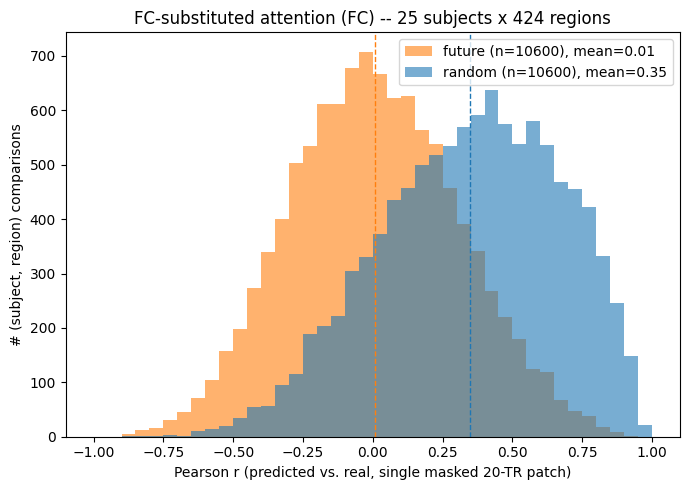

Pooled paired Wilcoxon (future vs. random, n=10600): statistic=7600842.0, p=0
future: mean=0.008, median=-0.000, std=0.301
random: mean=0.347, median=0.371, std=0.322
Saved 42400 rows -> outputs/fc_substituted_w0_correlations.csv


In [11]:
r_future_all = np.array([row["r"] for row in multi_results if row["condition"] == "future" and row["variant"] == "fc"])
r_random_all = np.array([row["r"] for row in multi_results if row["condition"] == "random" and row["variant"] == "fc"])

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future_all, bins=bins, alpha=0.6, color="tab:orange", label=f"future (n={len(r_future_all)}), mean={np.nanmean(r_future_all):.2f}")
ax.hist(r_random_all, bins=bins, alpha=0.6, color="tab:blue", label=f"random (n={len(r_random_all)}), mean={np.nanmean(r_random_all):.2f}")
ax.axvline(np.nanmean(r_future_all), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random_all), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# (subject, region) comparisons")
ax.set_title(f"FC-substituted attention (FC) -- {n_ok} subjects x {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_fc_substituted_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid_all = ~(np.isnan(r_future_all) | np.isnan(r_random_all))
stat_all, p_all = stats.wilcoxon(r_future_all[valid_all], r_random_all[valid_all])
print(f"Pooled paired Wilcoxon (future vs. random, n={int(valid_all.sum())}): statistic={stat_all:.1f}, p={p_all:.4g}")
print(f"future: mean={np.nanmean(r_future_all):.3f}, median={np.nanmedian(r_future_all):.3f}, std={np.nanstd(r_future_all):.3f}")
print(f"random: mean={np.nanmean(r_random_all):.3f}, median={np.nanmedian(r_random_all):.3f}, std={np.nanstd(r_random_all):.3f}")

csv_path = os.path.join(OUTPUTS_DIR, f"fc_substituted_w{WINDOW_INDEX}_correlations.csv")
with open(csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "region", "condition", "variant", "patch", "tr_start", "tr_end", "r"])
    writer.writeheader()
    writer.writerows(multi_results)
print(f"Saved {len(multi_results)} rows -> {csv_path}")

### FC vs. abs(FC): does the sign-flip pathology actually cost us anything?

Same subjects, same masked tokens, same condition -- only the sign of the FC values
fed into the substitution differs. If the sign-flipped rows found earlier were
distorting reconstruction, abs(FC) should score visibly higher.

future: FC mean=0.008, abs(FC) mean=0.039, paired Wilcoxon n=10600, statistic=25798046.0, p=3.265e-13
random: FC mean=0.347, abs(FC) mean=0.245, paired Wilcoxon n=10600, statistic=15003106.0, p=0


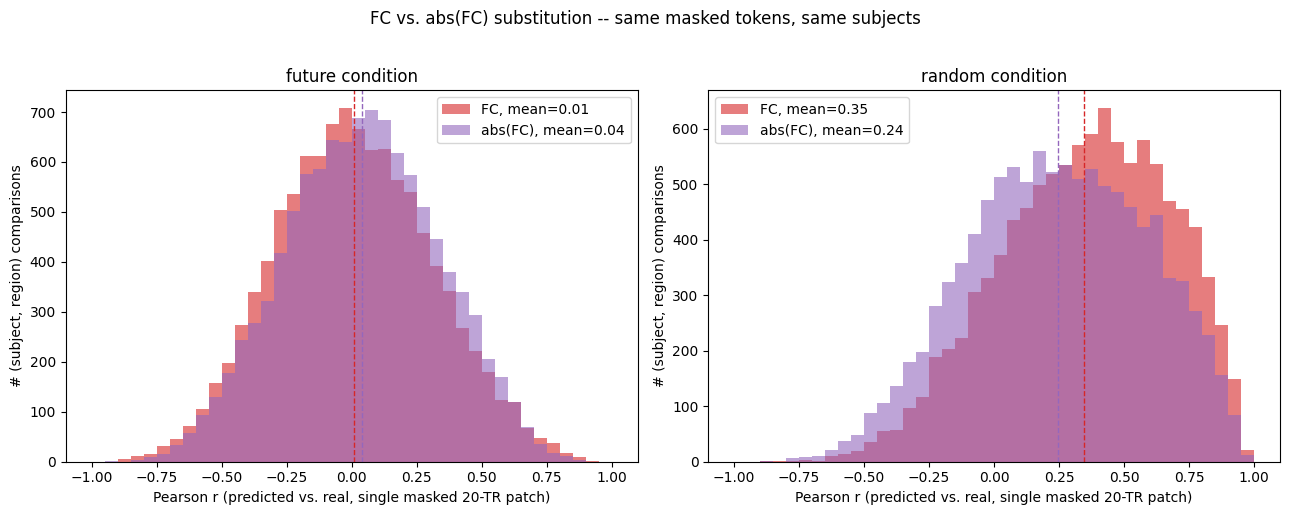

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(-1, 1, 41)

for ax, condition_k in zip(axes, ["future", "random"]):
    r_fc = np.array([row["r"] for row in multi_results if row["condition"] == condition_k and row["variant"] == "fc"])
    r_abs = np.array([row["r"] for row in multi_results if row["condition"] == condition_k and row["variant"] == "abs"])
    ax.hist(r_fc, bins=bins, alpha=0.6, color="tab:red", label=f"FC, mean={np.nanmean(r_fc):.2f}")
    ax.hist(r_abs, bins=bins, alpha=0.6, color="tab:purple", label=f"abs(FC), mean={np.nanmean(r_abs):.2f}")
    ax.axvline(np.nanmean(r_fc), color="tab:red", linestyle="--", linewidth=1)
    ax.axvline(np.nanmean(r_abs), color="tab:purple", linestyle="--", linewidth=1)
    ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
    ax.set_ylabel("# (subject, region) comparisons")
    ax.set_title(f"{condition_k} condition")
    ax.legend()

    valid_sa = ~(np.isnan(r_fc) | np.isnan(r_abs))
    stat_sa, p_sa = stats.wilcoxon(r_fc[valid_sa], r_abs[valid_sa])
    print(f"{condition_k}: FC mean={np.nanmean(r_fc):.3f}, abs(FC) mean={np.nanmean(r_abs):.3f}, "
          f"paired Wilcoxon n={int(valid_sa.sum())}, statistic={stat_sa:.1f}, p={p_sa:.4g}")

fig.suptitle("FC vs. abs(FC) substitution -- same masked tokens, same subjects", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"fc_vs_abs_fc_w{WINDOW_INDEX}_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()

### Per-subject breakdown: is the effect consistent across subjects? (FC)

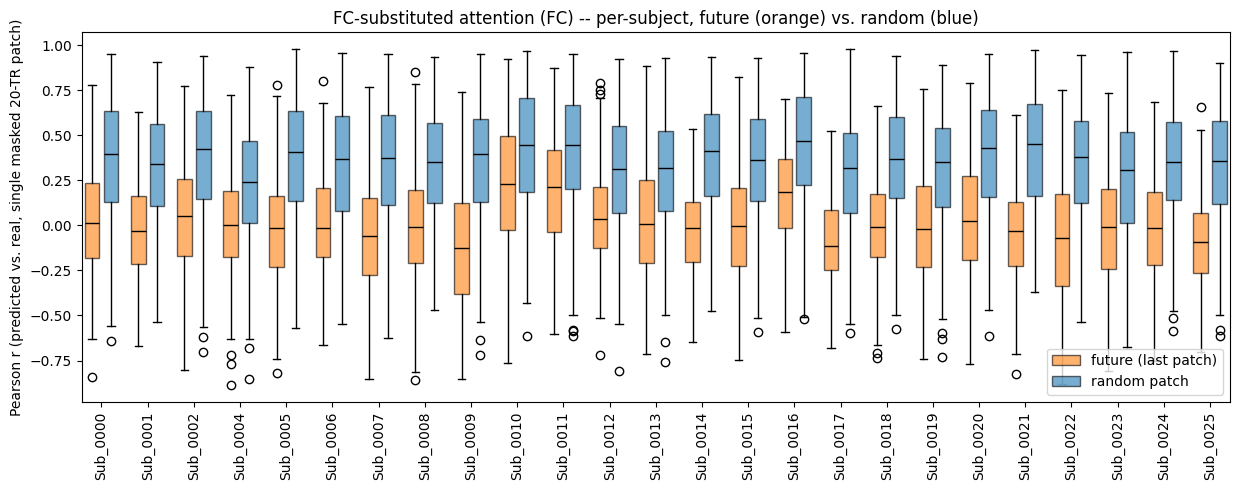

In [13]:
subject_order = list(dict.fromkeys(row["subject_id"] for row in multi_results))

future_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "future" and row["variant"] == "fc"]
                      for sid in subject_order]
random_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "random" and row["variant"] == "fc"]
                      for sid in subject_order]

positions_future = np.arange(len(subject_order)) * 2.2
positions_random = positions_future + 0.9

fig, ax = plt.subplots(1, 1, figsize=(max(10, len(subject_order) * 0.5), 5))
bp_f = ax.boxplot(future_by_subject, positions=positions_future, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:orange", alpha=0.6), medianprops=dict(color="black"))
bp_r = ax.boxplot(random_by_subject, positions=positions_random, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:blue", alpha=0.6), medianprops=dict(color="black"))
ax.set_xticks((positions_future + positions_random) / 2)
ax.set_xticklabels(subject_order, rotation=90)
ax.set_ylabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_title(f"FC-substituted attention (FC) -- per-subject, future (orange) vs. random (blue)")
ax.legend([bp_f["boxes"][0], bp_r["boxes"][0]], ["future (last patch)", "random patch"], loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_fc_substituted_per_subject.png"), dpi=130, bbox_inches="tight")
plt.show()

## The actual hypothesis test: original model vs. FC vs. abs(FC)

Loads `future_vs_random_w0_correlations.csv` from `future_vs_random_token_reconstruction.ipynb`
(same subjects, same seeds -> same masked patches) and compares its r-values directly
against both of this notebook's variants, per condition. If the diagonal attention
blocks really are "just FC", these distributions should be close; a large, consistent
drop for either FC-substituted variant is evidence the learned attention carries
information beyond FC. Comparing FC vs. abs(FC) against each other (not just each
against the original) isolates whether the earlier sign-flip pathology is actually
suppressing that effect, inflating it, or making no visible difference.


future:
  original model (mean=0.022) vs. FC-substituted (mean=0.008): paired Wilcoxon n=10600, statistic=26991538.0, p=0.0004743
  original model (mean=0.022) vs. FC-substituted (abs) (mean=0.039): paired Wilcoxon n=10600, statistic=24472903.0, p=1.5e-30
  FC-substituted (mean=0.008) vs. FC-substituted (abs) (mean=0.039): paired Wilcoxon n=10600, statistic=25798046.0, p=3.265e-13

random:
  original model (mean=0.159) vs. FC-substituted (mean=0.347): paired Wilcoxon n=10600, statistic=10535659.0, p=0
  original model (mean=0.159) vs. FC-substituted (abs) (mean=0.245): paired Wilcoxon n=10600, statistic=8951146.0, p=0
  FC-substituted (mean=0.347) vs. FC-substituted (abs) (mean=0.245): paired Wilcoxon n=10600, statistic=15003106.0, p=0


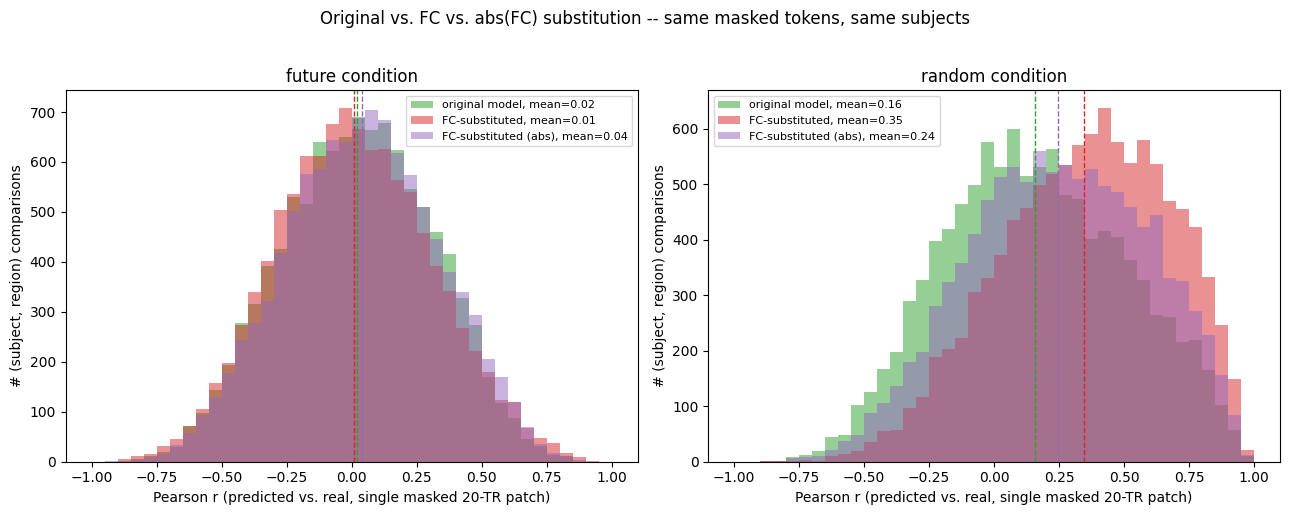

In [14]:
if not os.path.exists(ORIGINAL_MODEL_CSV):
    raise FileNotFoundError(
        f"{ORIGINAL_MODEL_CSV} not found -- run future_vs_random_token_reconstruction.ipynb first "
        "(same RANDOM_SEED, same N_SUBJECTS_MULTI) so there's a same-tokens baseline to compare against."
    )

with open(ORIGINAL_MODEL_CSV, newline="") as f_in:
    original_results = list(csv.DictReader(f_in))

orig_lookup = {(row["subject_id"], int(row["region"]), row["condition"]): float(row["r"]) for row in original_results}
fc_lookup = {(row["subject_id"], row["region"], row["condition"]): row["r"] for row in multi_results if row["variant"] == "fc"}
abs_lookup = {(row["subject_id"], row["region"], row["condition"]): row["r"] for row in multi_results if row["variant"] == "abs"}

paired = {c: {"orig": [], "fc": [], "abs": []} for c in ["future", "random"]}
missing = 0
for key, r_fc in fc_lookup.items():
    sub_id_k, region_k, condition_k = key
    if key not in orig_lookup or key not in abs_lookup:
        missing += 1
        continue
    paired[condition_k]["orig"].append(orig_lookup[key])
    paired[condition_k]["fc"].append(r_fc)
    paired[condition_k]["abs"].append(abs_lookup[key])

if missing:
    print(f"Note: {missing} (subject, region, condition) rows missing from one of the three sources "
          "(different N_SUBJECTS_MULTI between runs?) -- excluded from the paired comparison.")

COLORS = {"orig": "tab:green", "fc": "tab:red", "abs": "tab:purple"}
LABELS = {"orig": "original model", "fc": "FC-substituted", "abs": "FC-substituted (abs)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(-1, 1, 41)

for ax, condition_k in zip(axes, ["future", "random"]):
    vals = {k: np.array(v) for k, v in paired[condition_k].items()}
    for k in ["orig", "fc", "abs"]:
        ax.hist(vals[k], bins=bins, alpha=0.5, color=COLORS[k], label=f"{LABELS[k]}, mean={np.nanmean(vals[k]):.2f}")
        ax.axvline(np.nanmean(vals[k]), color=COLORS[k], linestyle="--", linewidth=1)
    ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
    ax.set_ylabel("# (subject, region) comparisons")
    ax.set_title(f"{condition_k} condition")
    ax.legend(fontsize=8)

    print(f"\n{condition_k}:")
    for a, b in [("orig", "fc"), ("orig", "abs"), ("fc", "abs")]:
        valid_pair = ~(np.isnan(vals[a]) | np.isnan(vals[b]))
        stat_pair, p_pair = stats.wilcoxon(vals[a][valid_pair], vals[b][valid_pair])
        print(f"  {LABELS[a]} (mean={np.nanmean(vals[a]):.3f}) vs. {LABELS[b]} (mean={np.nanmean(vals[b]):.3f}): "
              f"paired Wilcoxon n={int(valid_pair.sum())}, statistic={stat_pair:.1f}, p={p_pair:.4g}")

fig.suptitle("Original vs. FC vs. abs(FC) substitution -- same masked tokens, same subjects", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"original_vs_fc_substituted_w{WINDOW_INDEX}_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()